In [38]:
# Instructor Effectiveness Modeling
# This notebook analyzes batch-level learner outcome, engagement, and feedback data 
# to define an Instructor Effectiveness Score, aggregate it to the instructor level, 
# and predict effectiveness tiers (Low/Medium/High) using a Random Forest classifier.

# Sections:
# 1. Exploratory Data Analysis
# 2. Defining Instructor Effectiveness
# 3. Aggregating Batch-Level Data to Instructor Level
# 4. Model Building
# 5. Evaluation
# 6. Interpretation & Analysis Questions

In [39]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [40]:
df = pd.read_csv('instructor_effectiveness_dataset_2000_rows.csv')
df.head()

,batch_id,instructor_id,course_id,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
0,B_1861,I_044,C_01,0.300000,14.225955,73.546528,0.647423,0.774572,0.790918,0.108414,3.766211,0.533193
1,B_0354,I_119,C_06,0.657220,22.871110,77.312331,0.425098,0.494936,0.998566,0.280550,5.000000,0.734087
2,B_1334,I_050,C_03,0.300000,16.087517,79.563687,0.700000,0.977901,0.807298,0.207013,3.517386,0.681433
3,B_0906,I_024,C_21,0.639507,24.260687,99.295316,0.334657,0.846515,0.544555,0.306395,4.207578,1.000000
4,B_1290,I_001,C_08,0.527302,31.081556,99.393425,0.521099,0.917450,0.865885,0.252289,4.426230,0.696710


In [41]:
print(df.shape)
df.info()
df.isnull().sum()

(2000, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   batch_id                    2000 non-null   object 
 1   instructor_id               2000 non-null   object 
 2   course_id                   2000 non-null   object 
 3   completion_rate             2000 non-null   float64
 4   avg_score_improvement       2000 non-null   float64
 5   avg_quiz_score              2000 non-null   float64
 6   dropout_rate                2000 non-null   float64
 7   avg_watch_time              2000 non-null   float64
 8   assignment_submission_rate  2000 non-null   float64
 9   forum_activity_rate         2000 non-null   float64
 10  avg_feedback_score          2000 non-null   float64
 11  feedback_response_rate      2000 non-null   float64
dtypes: float64(9), object(3)
memory usage: 187.6+ KB


batch_id                      0
instructor_id                 0
course_id                     0
completion_rate               0
avg_score_improvement         0
avg_quiz_score                0
dropout_rate                  0
avg_watch_time                0
assignment_submission_rate    0
forum_activity_rate           0
avg_feedback_score            0
feedback_response_rate        0
dtype: int64

In [42]:
print(df['instructor_id'].nunique())
print(df['course_id'].nunique())
df['instructor_id'].value_counts()

120
25


instructor_id
I_062    31
I_101    27
I_099    26
I_033    26
I_092    26
         ..
I_041     8
I_091     8
I_077     8
I_031     8
I_102     7
Name: count, Length: 120, dtype: int64

In [43]:
df.describe()

,completion_rate,avg_score_improvement,avg_quiz_score,dropout_rate,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000
mean,0.602808,27.035844,77.956126,0.394883,0.776515,0.753188,0.250300,4.207134,0.736519
std,0.159667,5.716641,10.695618,0.162747,0.145231,0.148058,0.100640,0.419209,0.149412
min,0.300000,6.159240,40.386725,0.020000,0.287440,0.251111,0.000000,2.639915,0.259935
25%,0.489260,23.124673,70.897590,0.280035,0.675076,0.652110,0.179845,3.918986,0.633293
50%,0.603091,26.938629,78.020567,0.394820,0.780330,0.756380,0.249771,4.205989,0.737213
75%,0.712797,30.885600,85.444286,0.511432,0.894242,0.856458,0.319204,4.503437,0.845876
max,0.980000,40.000000,100.000000,0.700000,1.000000,1.000000,0.641111,5.000000,1.000000


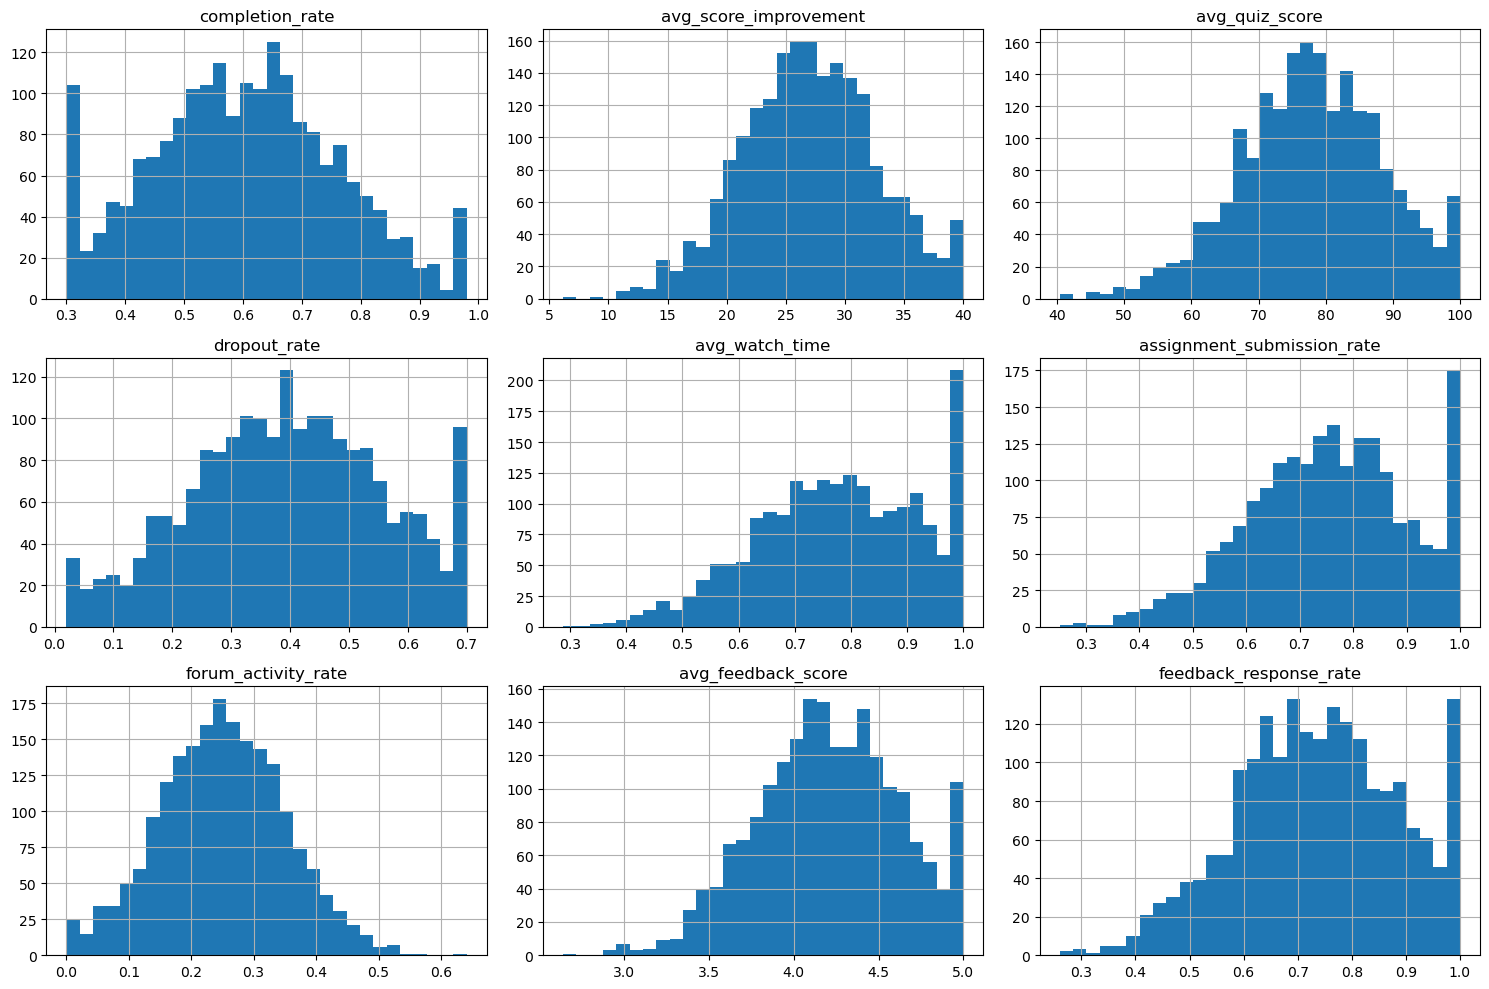

In [44]:
df.hist(figsize=(15, 10), bins=30)
plt.tight_layout()
plt.show()

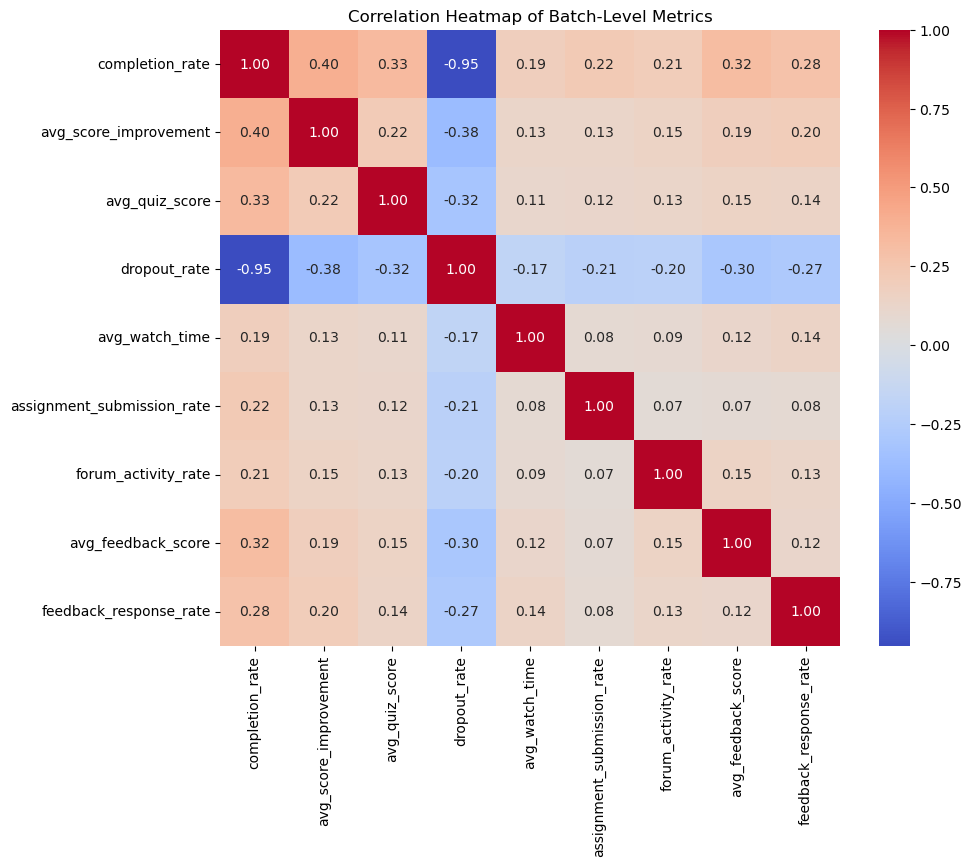

In [45]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Batch-Level Metrics')
plt.show()

In [46]:
# Convert dropout_rate to retention (higher = better, same direction as other metrics)
df['retention_rate'] = 1 - df['dropout_rate']

from sklearn.preprocessing import MinMaxScaler

outcome_cols = ['completion_rate', 'retention_rate', 'avg_score_improvement', 'avg_quiz_score']
engagement_cols = ['avg_watch_time', 'assignment_submission_rate', 'forum_activity_rate']
feedback_cols = ['avg_feedback_score', 'feedback_response_rate']

scaler = MinMaxScaler()
scaled = pd.DataFrame(scaler.fit_transform(df[outcome_cols + engagement_cols + feedback_cols]),
                       columns=outcome_cols + engagement_cols + feedback_cols)

df['outcome_score'] = scaled[outcome_cols].mean(axis=1)
df['engagement_score'] = scaled[engagement_cols].mean(axis=1)
df['feedback_score'] = scaled[feedback_cols].mean(axis=1)

df['effectiveness_score'] = (0.5 * df['outcome_score'] +
                              0.3 * df['engagement_score'] +
                              0.2 * df['feedback_score'])
df[['instructor_id','effectiveness_score']].head()

,instructor_id,effectiveness_score
0,I_044,0.350994
1,I_119,0.592113
2,I_050,0.416412
3,I_024,0.651812
4,I_001,0.635021


In [47]:
instructor_df = df.groupby('instructor_id').agg(
    num_batches=('batch_id','count'),
    completion_rate=('completion_rate','mean'),
    dropout_rate=('dropout_rate','mean'),
    avg_score_improvement=('avg_score_improvement','mean'),
    avg_quiz_score=('avg_quiz_score','mean'),
    avg_watch_time=('avg_watch_time','mean'),
    assignment_submission_rate=('assignment_submission_rate','mean'),
    forum_activity_rate=('forum_activity_rate','mean'),
    avg_feedback_score=('avg_feedback_score','mean'),
    feedback_response_rate=('feedback_response_rate','mean'),
    effectiveness_score=('effectiveness_score','mean')
).reset_index()

instructor_df.head()

,instructor_id,num_batches,completion_rate,dropout_rate,avg_score_improvement,avg_quiz_score,avg_watch_time,assignment_submission_rate,forum_activity_rate,avg_feedback_score,feedback_response_rate,effectiveness_score
0,I_001,25,0.543887,0.470593,26.641462,78.900194,0.766513,0.726893,0.240551,4.217743,0.694858,0.537324
1,I_002,20,0.730874,0.247194,30.166242,81.737198,0.837393,0.774394,0.289610,4.343002,0.784338,0.673072
2,I_003,18,0.768447,0.234828,29.977813,81.590928,0.818441,0.779606,0.296224,4.450034,0.812132,0.688608
3,I_004,17,0.458328,0.547261,22.912021,77.680317,0.793130,0.758317,0.226259,4.076410,0.721460,0.494478
4,I_005,19,0.859747,0.145733,32.588652,85.828159,0.847026,0.876942,0.333519,4.202516,0.784197,0.748861


In [48]:
instructor_df['effectiveness_tier'] = pd.qcut(instructor_df['effectiveness_score'], 3, labels=['Low','Medium','High'])
instructor_df['effectiveness_tier'].value_counts()

effectiveness_tier
Low       40
Medium    40
High      40
Name: count, dtype: int64

In [49]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

feature_cols = ['completion_rate','dropout_rate','avg_score_improvement','avg_quiz_score',
                 'avg_watch_time','assignment_submission_rate','forum_activity_rate',
                 'avg_feedback_score','feedback_response_rate']

X = instructor_df[feature_cols]
y = instructor_df['effectiveness_tier']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler2 = StandardScaler()
X_train_scaled = scaler2.fit_transform(X_train)
X_test_scaled = scaler2.transform(X_test)

model = RandomForestClassifier(n_estimators=200, random_state=42)
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)
print(accuracy_score(y_test, y_pred))
print(classification_report(y_test, y_pred))

0.9166666666666666
              precision    recall  f1-score   support

        High       1.00      0.88      0.93         8
         Low       1.00      0.88      0.93         8
      Medium       0.80      1.00      0.89         8

    accuracy                           0.92        24
   macro avg       0.93      0.92      0.92        24
weighted avg       0.93      0.92      0.92        24



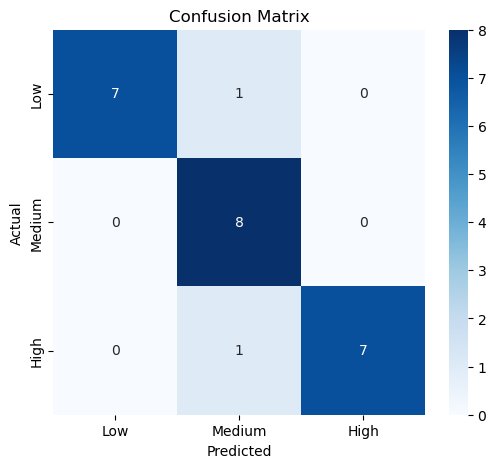

In [50]:
cm = confusion_matrix(y_test, y_pred, labels=['Low','Medium','High'])
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

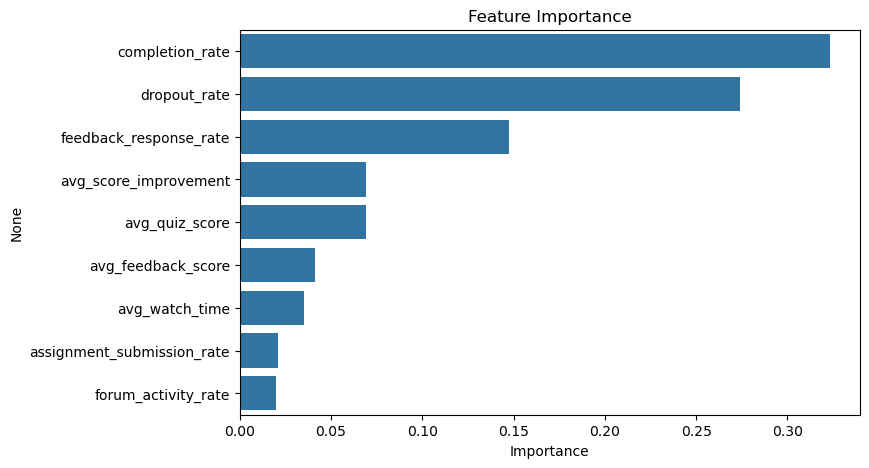

completion_rate               0.323428
dropout_rate                  0.273997
feedback_response_rate        0.147470
avg_score_improvement         0.069254
avg_quiz_score                0.069147
avg_feedback_score            0.041403
avg_watch_time                0.034999
assignment_submission_rate    0.020728
forum_activity_rate           0.019573
dtype: float64


In [51]:
importances = pd.Series(model.feature_importances_, index=feature_cols).sort_values(ascending=False)
plt.figure(figsize=(8,5))
sns.barplot(x=importances.values, y=importances.index)
plt.title('Feature Importance')
plt.xlabel('Importance')
plt.show()
print(importances)

In [52]:
## Conclusion
# This analysis defined instructor effectiveness as a weighted combination of learner 
# outcomes (50%), engagement (30%), and feedback (20%), aggregated from 2000 batch-level 
# records to 120 instructors. A Random Forest classifier achieved 92% accuracy predicting 
# effectiveness tiers, with completion_rate and dropout_rate as the dominant predictors. 
# While the model performs well on this dataset, it should be used as a decision-support 
# tool alongside human judgment rather than a standalone evaluation mechanism, given 
# potential confounds like course difficulty and cohort variation that aren't captured 
# in the current data.